## Preparation

### Libraries import & metadata storage definitions

In [2]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
checkpoint_dir = "checkpoints"
graph_dir = "regnet_graphs"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Dataset and model download & instantiation

В работе рассматривается задача классификации изображений, для которой используются модель семейства RegNet версии RegNet_X_3_2_GF и датасет CIFAR-100. 

Датасет CIFAR-100 содержит 60 000 цветных изображений (50 000 в подсете train и 10 000 в подсете test) размерности 32х32 пикселя, каждое из которых соотносится ровно с 1 из 100 классов. Классы сбалансированы: каждый класс представлен 600 изображениями.

Модель для ускорения обучения инициализируется весами, предобученными на датасете [ImageNet](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview) со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992
с дальнейшей адаптацией архитектуры под CIFAR-100.

In [5]:
def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_train = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

In [6]:
dataset_dir_cifar100 = "/home/user/Desktop/o-net-experiments/regnetx_imagenet/D:/cifar100"
n_classes = 100
batch_size = 128
num_workers = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


In [7]:
print("[ ] Creating train & val dataloaders for CIFAR-100...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Train & val ataloaders for CIFAR-100 created")

[ ] Creating train & val dataloaders for CIFAR-100...
[V] Train & val ataloaders for CIFAR-100 created


In [8]:
def adapt_model_cifar100(model, 
                         n_classes: int,
                         in_channels: int = 3, 
                         out_channels: int = 32,
                         kernel_size: int = 3,
                         stride: int = 1, 
                         padding: int = 1,
                         bias: bool = False):
    model.stem[0] = torch.nn.Conv2d(
        in_channels = in_channels, out_channels = out_channels, 
        kernel_size=kernel_size, stride=stride, padding=padding, 
        bias=bias
    )
    model.fc = torch.nn.Linear(model.fc.in_features, n_classes)


In [9]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.to(device)
print("[V] Model instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] Model instantiated and adapted for CIFAR-100


### Common key functions

In [10]:
def plot_metrics(trains: list, 
                 tests: list, 
                 epochs: int, 
                 metric_name: str = "metric",
                 graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i * len(trains)//len(tests) for i in range(len(tests))], 
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()
    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))

In [11]:
def train_epoch(model: torch.nn.Module,
                train_loader: DataLoader,
                optimizer,
                criterion,
                device: torch.device = torch.device("cpu")):
    model.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
        
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_acc = 100. * correct / total

    return train_loss, train_acc


def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc


def train_n_epochs(model: torch.nn.Module,
                   train_loader: DataLoader, 
                   test_loader: DataLoader,
                   optimizer,
                   criterion,
                   scheduler,
                   device: torch.device = torch.device("cpu"),
                   epochs: int = 150,
                   checkpoint_dir: str = "checkpoints",
                   with_plots: bool = True,
                   graph_dir: str = "",
                   verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model.to(device)
    model_name = model.__class__.__name__

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_last_{epochs}epochs.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_best_{epochs}epochs.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

    if with_plots:
        graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
        os.makedirs(graph_dir, exist_ok=True)
        plot_metrics(train_losses, test_losses, epochs, metric_name="loss", graph_dir=graph_dir)
        plot_metrics(train_accs, test_accs, epochs, metric_name="acc", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")

In [12]:
max_lr = 0.01  # 0.001 recommended for ResNet18 finetuning on CIFAR-100
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

### Fine-tuning RegNetX_3_2 on CIFAR-100

We can pre-finetune model...

In [ ]:
print("[ ] Finetuning model on CIFAR-100...")
train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device, 
    epochs=10,
    checkpoint_dir=checkpoint_dir,
    graph_dir=graph_dir
)
print("[V] Model finetuned on CIFAR-100")

Or download it fine-tuned from checkpoint:

In [21]:
checkpoint_path = "/home/user/Desktop/o-net-experiments/regnetx_imagenet/checkpoints_100epochs/regnet_cifar100_best_100epochs.pth"
print("[ ] Loading checkpoints from path:", checkpoint_path, "...")
checkpoint = torch.load(checkpoint_path)
print("[V] Checkpoints loaded")

print("[ ] Loading fine-tuned model for CIFAR-100...")
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

[ ] Loading checkpoints from path: /home/user/Desktop/o-net-experiments/regnetx_imagenet/checkpoints_100epochs/regnet_cifar100_best_100epochs.pth ...
[V] Checkpoints loaded
[ ] Loading fine-tuned model for CIFAR-100...
[V] Fine-tuned model loaded, its accuracy: 56.66


In [22]:
print("[ ] Validating model to check accuracy...")
_, checkpoint_acc = validate_epoch(regnetx_3_2, val_loader, criterion, device)
print("[V] Model has accuracy:", checkpoint_acc)

[ ] Validating model to check accuracy...
[V] Model has accuracy: 56.66


But further a new model will be used.

## Iterative augmentation

### Dataloader creation

In [13]:
def make_train_loader_cifar100_augmented(data_dir: str, 
                                         batch_size: int = 256, 
                                         num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.5, 
            contrast=0.5, 
            hue=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_train = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

In [14]:
print("[ ] Creating dataloader for augmented CIFAR-100...")
train_loader_aug = make_train_loader_cifar100_augmented(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Dataloader for augmented CIFAR-100 created")

[ ] Creating dataloader for augmented CIFAR-100...
[V] Dataloader for augmented CIFAR-100 created


In [15]:
def display_classes_examples(dataloader, classes_ids, n_examples: int=3):  
    classes_names = [dataloader.dataset.classes[class_id] for class_id in classes_ids]
    classes = {
        class_id: class_name
        for class_id, class_name in zip(classes_ids, classes_names)
    }
    images_to_show = []
    captions = []
    
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            for image, label in zip(batch_images, batch_labels):
                label_num = label.item()
                if label_num in classes_ids:
                    class_name = classes[label_num]
                    if captions.count(class_name) < n_examples:
                        images_to_show.append(image)
                        captions.append(class_name)
            
            if all(captions.count(class_id) >= n_examples for class_id in classes_ids):
                break
    
    fig, axes = plt.subplots(
        len(classes_ids), 
        n_examples, 
        figsize=(n_examples * 2, len(classes_names) * 2)
    )
    
    for i, class_name in enumerate(classes_names):
        indices = [id for id, caption in enumerate(captions) if (caption == class_name)][:n_examples]
        
        for j, idx in enumerate(indices):
            ax = axes[i][j]
            image = images_to_show[idx].numpy().transpose(1, 2, 0)
            
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            ax.imshow(image)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

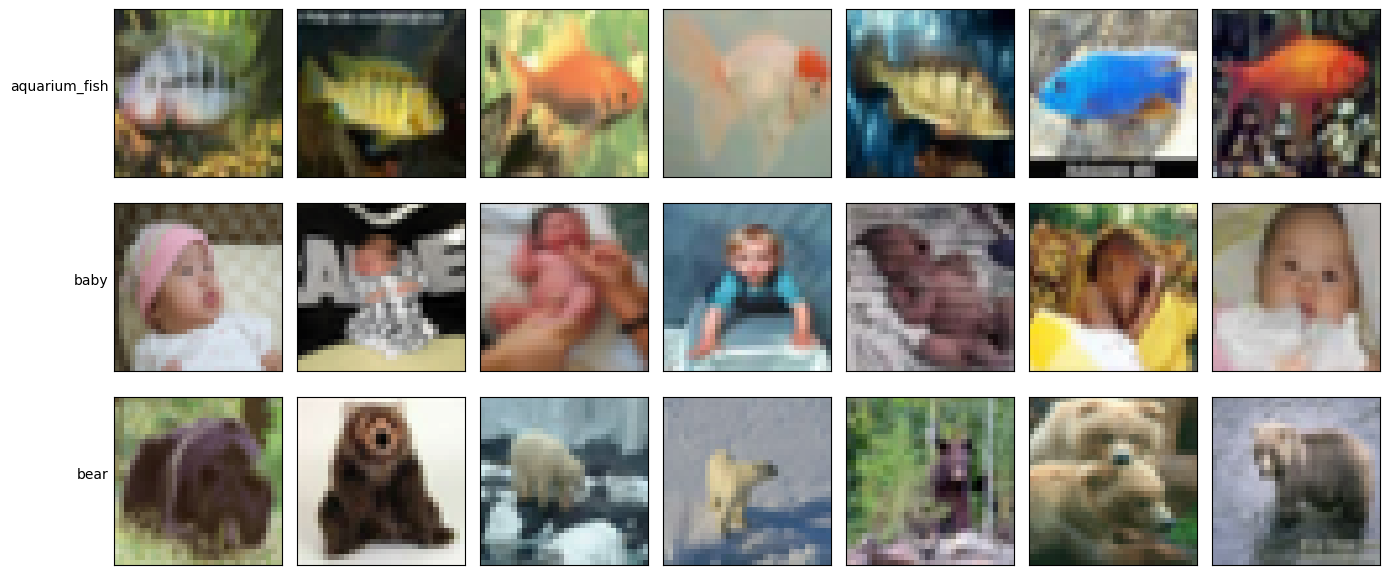

In [16]:
display_classes_examples(train_loader, [1, 2, 3], 7)

### Learning loop

In [17]:
n_iterations = 5
n_epochs_train = 10
n_epochs_finetune = 10

In [ ]:
train_aug_losses = []
train_aug_accs = []
test_aug_losses = []
test_aug_accs = []

for iteration in range(n_iterations):
    print(f"\nLearning iteration {iteration + 1}/{n_iterations}:\n")
    
    graph_subdir_iteration = os.path.join(graph_dir, f"iteration_{iteration}")
    
    print("    [ ] Training on augmented train set...")
    train_n_epochs(
        regnetx_3_2, 
        train_loader_aug, 
        val_loader, 
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=device, 
        epochs=n_epochs_train,
        checkpoint_dir=checkpoint_dir,
        with_plots=True,
        graph_dir = os.path.join(graph_subdir_iteration, "train")
    )
    print("    [V] Training on augmented train set finished")

    print("    [ ] Finetuning on normal train set...")
    train_n_epochs(
        regnetx_3_2, 
        train_loader, 
        val_loader, 
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=device, 
        epochs=n_epochs_finetune,
        checkpoint_dir=checkpoint_dir,
        with_plots=True,
        graph_dir = os.path.join(graph_subdir_iteration, "finetune")
    )
    print("    [V] Finetuning on normal train set finished!")
    
    print("Results of training via iterative augmentation are saved in the following folders:")
    print("    graphs:     ", graph_dir)
    print("    checkpoints:", checkpoint_dir)



Learning iteration 1/5:

    [ ] Training on augmented train set...
Epoch 0 started...


## Iterative layer unfreeze

## Pseudolabelling